# Problem Title - Library Mode
Issue: #4

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [37]:
import torch
from torch import nn
import pandas as pd

In [38]:
# Set device agnostic
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [39]:
df = pd.read_csv("/content/dataset.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [41]:
df['quality'].nunique(), df['quality_binary'].nunique()

(7, 2)

In [42]:
df.columns, len(df.columns)

(Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary'],
       dtype='object'),
 13)

## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [43]:
X = df[['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol']]

y = df['quality_binary']

X[:5], y[:5]

(   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
 0            7.4              0.70         0.00             1.9      0.076   
 1            7.8              0.88         0.00             2.6      0.098   
 2            7.8              0.76         0.04             2.3      0.092   
 3           11.2              0.28         0.56             1.9      0.075   
 4            7.4              0.70         0.00             1.9      0.076   
 
    free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
 0                 11.0                  34.0   0.9978  3.51       0.56   
 1                 25.0                  67.0   0.9968  3.20       0.68   
 2                 15.0                  54.0   0.9970  3.26       0.65   
 3                 17.0                  60.0   0.9980  3.16       0.58   
 4                 11.0                  34.0   0.9978  3.51       0.56   
 
    alcohol  
 0      9.4  
 1      9.8  
 2      9.8  
 3      9.8  
 4

In [44]:
X_tensor = torch.from_numpy(X.values).to(device)
y_tensor = torch.from_numpy(y.values).to(device)

X_tensor, y_tensor

(tensor([[ 7.4000,  0.7000,  0.0000,  ...,  3.5100,  0.5600,  9.4000],
         [ 7.8000,  0.8800,  0.0000,  ...,  3.2000,  0.6800,  9.8000],
         [ 7.8000,  0.7600,  0.0400,  ...,  3.2600,  0.6500,  9.8000],
         ...,
         [ 6.5000,  0.2400,  0.1900,  ...,  2.9900,  0.4600,  9.4000],
         [ 5.5000,  0.2900,  0.3000,  ...,  3.3400,  0.3800, 12.8000],
         [ 6.0000,  0.2100,  0.3800,  ...,  3.2600,  0.3200, 11.8000]],
        dtype=torch.float64),
 tensor([0, 0, 0,  ..., 0, 1, 0]))

In [45]:
X_tensor.shape, y_tensor.shape

(torch.Size([6497, 11]), torch.Size([6497]))

In [46]:
input_shape = X_tensor[0].shape[0]
output_shape = 1
input_shape, output_shape

(11, 1)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

(tensor([[6.6000e+00, 2.4000e-01, 3.5000e-01,  ..., 3.1900e+00, 3.7000e-01,
          1.0500e+01],
         [8.3000e+00, 2.8000e-01, 4.8000e-01,  ..., 3.2600e+00, 6.2000e-01,
          1.2400e+01],
         [7.7000e+00, 7.1500e-01, 1.0000e-02,  ..., 3.4100e+00, 5.7000e-01,
          1.1800e+01],
         ...,
         [6.4000e+00, 3.7000e-01, 2.0000e-01,  ..., 3.2400e+00, 4.3000e-01,
          9.5000e+00],
         [6.5000e+00, 2.6000e-01, 5.0000e-01,  ..., 3.1800e+00, 4.7000e-01,
          9.5000e+00],
         [7.2000e+00, 6.2000e-01, 6.0000e-02,  ..., 3.5100e+00, 5.4000e-01,
          9.5000e+00]], dtype=torch.float64),
 tensor([[ 7.0000,  0.1700,  0.7400,  ...,  3.2600,  0.3800, 12.2000],
         [ 7.7000,  0.6400,  0.2100,  ...,  3.2700,  0.4500,  9.9000],
         [ 6.8000,  0.3900,  0.3400,  ...,  3.1800,  0.4400, 12.0000],
         ...,
         [ 6.6000,  0.1600,  0.3500,  ...,  3.1900,  0.7500, 12.4000],
         [ 6.6000,  0.3900,  0.3800,  ...,  3.3000,  0.5700,  9.4000],


In [48]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [49]:
class Model(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.block_1(x)

In [50]:
model = Model(input_shape=input_shape, hidden_units=8, output_shape=output_shape).to(device)
model

Model(
  (block_1): Sequential(
    (0): Linear(in_features=11, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

### 5.1 Functionizing Training and testing step

In [51]:
try:
  import torchmetrics
except:
  !pip install torchmetrics
  import torchmetrics

In [52]:
# Set the loss function and accuracy function
from torchmetrics import Accuracy

loss_fn = nn.BCEWithLogitsLoss()
accuracy_fn = Accuracy(task='binary', num_classes=1)

In [53]:
# Create train and test step
def train_step(model: nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn: Accuracy,
               device: torch.device = device):
  # Set the model to train mode and also set device
  model.train().to(device)

  train_loss, train_accuracy = 0, 0

  # Set up a loop to train based on batch
  for X, y in data_loader:

    # Set the data to the target device
    X, y = X.to(device).to(torch.float32), y.to(device).to(torch.float32)

    # Forward pass
    y_logits = model(X).squeeze()

    # Calculate the loss and accuracy
    loss = loss_fn(y_logits, y)
    train_loss += loss
    train_accuracy += accuracy_fn(torch.round(y_logits.sigmoid()), y)

    # Optimizer zero grad
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Optimizer step
    optimizer.step()

  train_loss /= len(data_loader)
  train_accuracy /= len(data_loader)

  return train_loss.item(), train_accuracy.item()

def test_step(model: nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: nn.Module,
               accuracy_fn: Accuracy,
               device: torch.device = device):
  # Set the model to train mode and also set device
  model.eval().to(device)

  test_loss, test_accuracy = 0, 0
  with torch.inference_mode():
    for X, y in data_loader:

      # Set the data to the target device
      X, y = X.to(device).to(torch.float32), y.to(device).to(torch.float32)

      # Forward pass
      y_logits = model(X).squeeze()

      # Calculate the loss and accuracy
      test_loss += loss_fn(y_logits, y)
      test_accuracy += accuracy_fn(torch.round(y_logits.sigmoid()), y)

    test_loss /= len(data_loader)
    test_accuracy /= len(data_loader)

  return test_loss.item(), test_accuracy.item()



In [54]:
def train_model(model: nn.Module,
                train_dataloader: torch.utils.data.DataLoader,
                test_dataloader: torch.utils.data.DataLoader,
                epochs: int,
                loss_fn: nn.Module,
                optimizer: torch.optim.Optimizer,
                accuracy_fn: Accuracy,
                device: torch.device = device
                ):
  train_losses = []
  test_losses = []
  train_accuracies = []
  test_accuracies = []

  for epoch in range(epochs):
    train_loss, train_accuracy = train_step(model=model,
                                            data_loader=train_dataloader,
                                            loss_fn=loss_fn,
                                            optimizer=optimizer,
                                            accuracy_fn=accuracy_fn,
                                            device=device)
    test_loss, test_accuracy = test_step(model=model,
                                        data_loader=test_dataloader,
                                        loss_fn=loss_fn,
                                        accuracy_fn=accuracy_fn,
                                        device=device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

  return train_losses, test_losses, train_accuracies, test_accuracies

In [55]:
def build_model_fn():
  return Model(input_shape=input_shape, hidden_units=8, output_shape=output_shape).to(device)

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import itertools

def run_pytorch_grid_search(train_dataset, test_dataset, batch_sizes, learning_rates, epochs=10):
    """
    Iterates through combinations of batch sizes and learning rates in PyTorch.
    """
    all_results = {}
    combinations = list(itertools.product(batch_sizes, learning_rates))
    print(f"Starting PyTorch Grid Search. Testing {len(combinations)} combinations...\n")

    # Setup loss function and accuracy function
    loss_fn = nn.BCEWithLogitsLoss()
    accuracy_fn = Accuracy(task='binary', num_classes=1)


    for batch_size, lr in combinations:
        experiment_name = f"BS_{batch_size}_LR_{lr}"
        print(f"--- Training: {experiment_name} ---")

        # 1. Build a FRESH model
        model = build_model_fn()

        # 2. Create a FRESH optimizer with the specific learning rate
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # 3. Create a FRESH DataLoader with the specific batch size
        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        model_results = train_model(model=model,
                                    train_dataloader=train_dataloader,
                                    test_dataloader=test_dataloader,
                                    epochs=epochs,
                                    loss_fn=loss_fn,
                                    optimizer=optimizer,
                                    accuracy_fn=accuracy_fn,
                                    device=device)

        # Save the history and print final epoch result
        all_results[experiment_name] = model_results

        latest_train_loss = model_results[0][-1]
        latest_test_loss = model_results[1][-1]
        latest_train_acc = model_results[2][-1]
        latest_test_acc = model_results[3][-1]

        print(f"Train Loss: {latest_train_loss:.4f} | Test Loss: {latest_test_loss:.4f}")
        print(f"Train Acc:  {(latest_train_acc*100):.2f}% | Test Acc:  {(latest_test_acc*100):.2f}%\n")

    return all_results

In [57]:
EPOCHS = 20

results = run_pytorch_grid_search(train_dataset=train_dataset,
                        test_dataset=test_dataset,
                        batch_sizes=[8, 32, 64],
                        learning_rates=[0.1, 0.01, 0.001],
                        epochs=EPOCHS)

Starting PyTorch Grid Search. Testing 9 combinations...

--- Training: BS_8_LR_0.1 ---
Train Loss: 0.5002 | Test Loss: 0.4931
Train Acc:  80.27% | Test Acc:  80.52%

--- Training: BS_8_LR_0.01 ---
Train Loss: 0.4289 | Test Loss: 0.4159
Train Acc:  80.28% | Test Acc:  80.52%

--- Training: BS_8_LR_0.001 ---
Train Loss: 0.4229 | Test Loss: 0.4248
Train Acc:  80.70% | Test Acc:  81.06%

--- Training: BS_32_LR_0.1 ---
Train Loss: 0.4977 | Test Loss: 0.4935
Train Acc:  80.29% | Test Acc:  80.52%

--- Training: BS_32_LR_0.01 ---
Train Loss: 0.4154 | Test Loss: 0.4352
Train Acc:  80.63% | Test Acc:  80.34%

--- Training: BS_32_LR_0.001 ---
Train Loss: 0.4475 | Test Loss: 0.4387
Train Acc:  80.11% | Test Acc:  80.44%

--- Training: BS_64_LR_0.1 ---
Train Loss: 0.4970 | Test Loss: 0.4982
Train Acc:  80.32% | Test Acc:  80.27%

--- Training: BS_64_LR_0.01 ---
Train Loss: 0.4205 | Test Loss: 0.4334
Train Acc:  80.83% | Test Acc:  80.13%

--- Training: BS_64_LR_0.001 ---
Train Loss: 0.4522 | Test 

In [58]:
results

{'BS_8_LR_0.1': ([0.5317636728286743,
   0.4994508624076843,
   0.4999108910560608,
   0.4986635744571686,
   0.5008185505867004,
   0.5005810856819153,
   0.49965885281562805,
   0.49988657236099243,
   0.5011245608329773,
   0.500420868396759,
   0.49975326657295227,
   0.5009791254997253,
   0.4992387890815735,
   0.49951180815696716,
   0.5006952285766602,
   0.4999970495700836,
   0.4999454915523529,
   0.5000503659248352,
   0.4995168447494507,
   0.5002319812774658],
  [0.49314084649086,
   0.4934326410293579,
   0.4935305416584015,
   0.49917420744895935,
   0.4958760440349579,
   0.49343377351760864,
   0.5007921457290649,
   0.5015477538108826,
   0.49308815598487854,
   0.4931270480155945,
   0.49391692876815796,
   0.4965970516204834,
   0.4993625581264496,
   0.49474579095840454,
   0.49403390288352966,
   0.4939853250980377,
   0.49493712186813354,
   0.493191123008728,
   0.49377015233039856,
   0.4931187033653259],
  [0.799307644367218,
   0.8028846383094788,
   0.80276

## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

In [59]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(epoch_count_list: list[int],
                       train_loss_list: list[float],
                       test_loss_list: list[float],
                       train_accuracy_list: list[float],
                       test_accuracy_list: list[float],
                       expeirment_name: str = ""):
  # Loss Curve
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(epoch_count_list, train_loss_list, 'r', label='Training Loss')
  plt.plot(epoch_count_list, test_loss_list, 'b', label='Validation Loss')
  plt.title(f'{experiment_name} Model Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  # Accuracy Curve
  plt.subplot(1, 2, 2)
  plt.plot(epoch_count_list, train_accuracy_list, 'r', label='Training Accuracy')
  plt.plot(epoch_count_list, test_accuracy_list, 'b', label='Validation Accuracy')
  plt.title(f'{experiment_name} Model Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

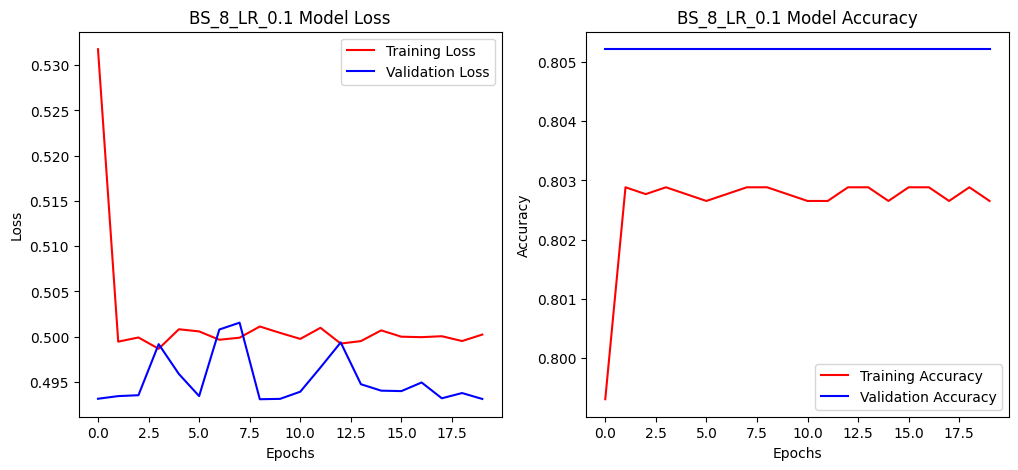

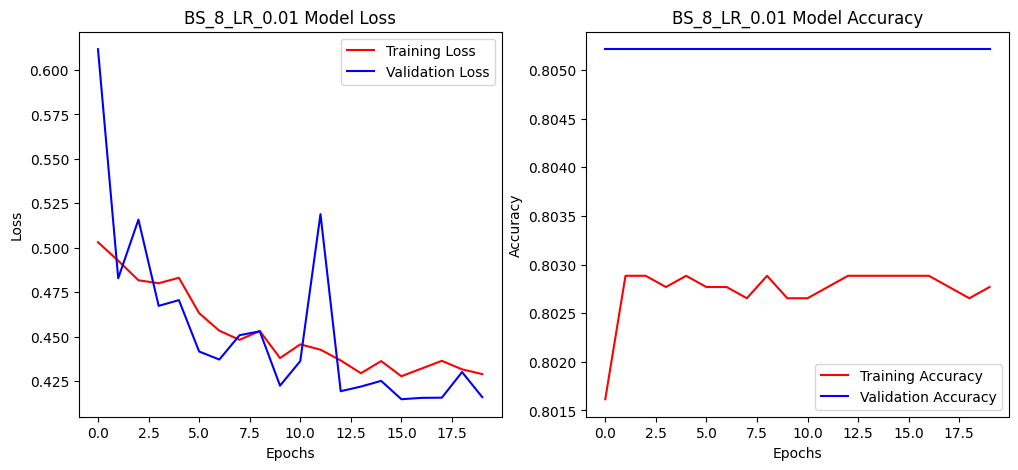

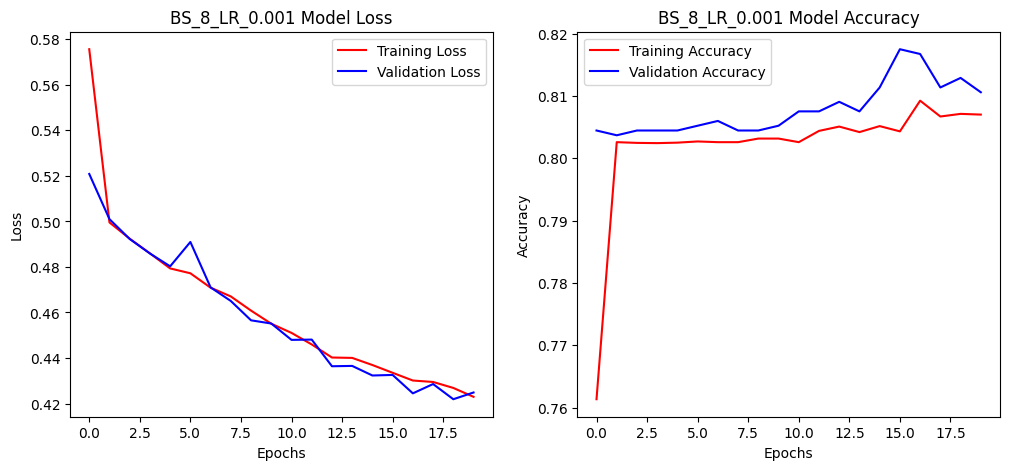

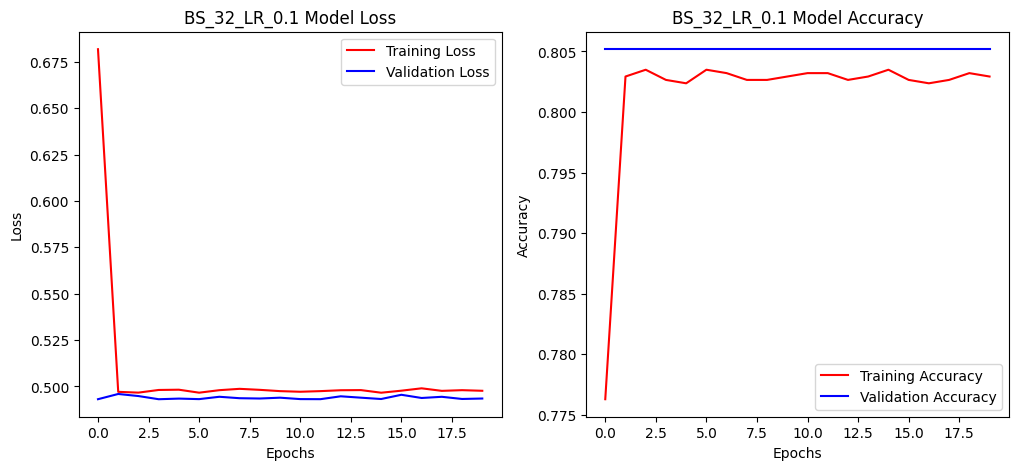

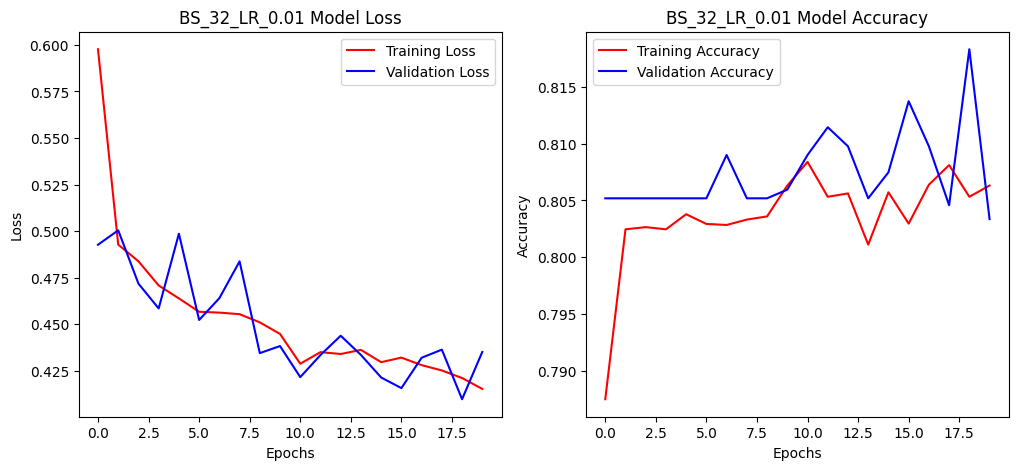

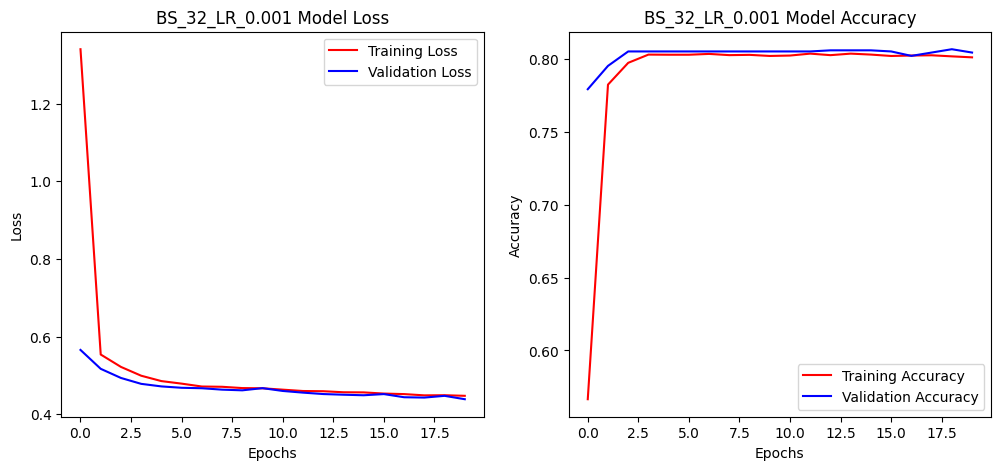

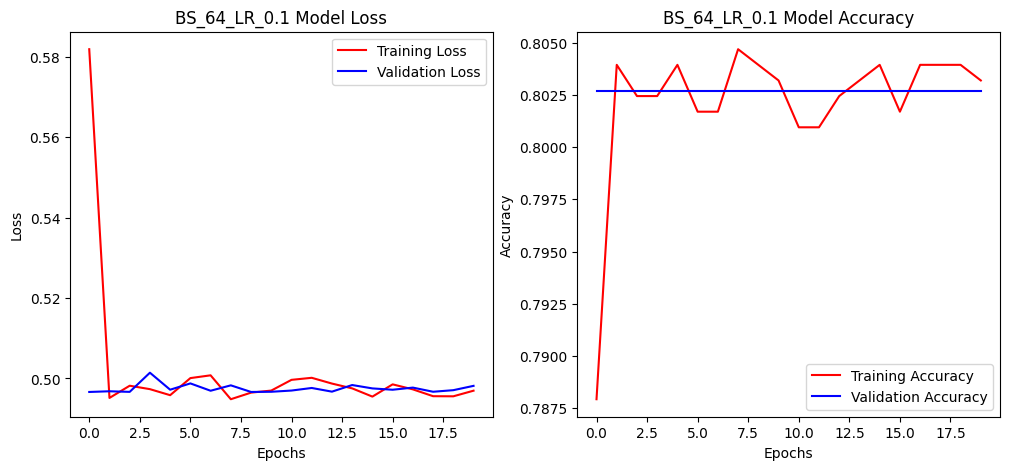

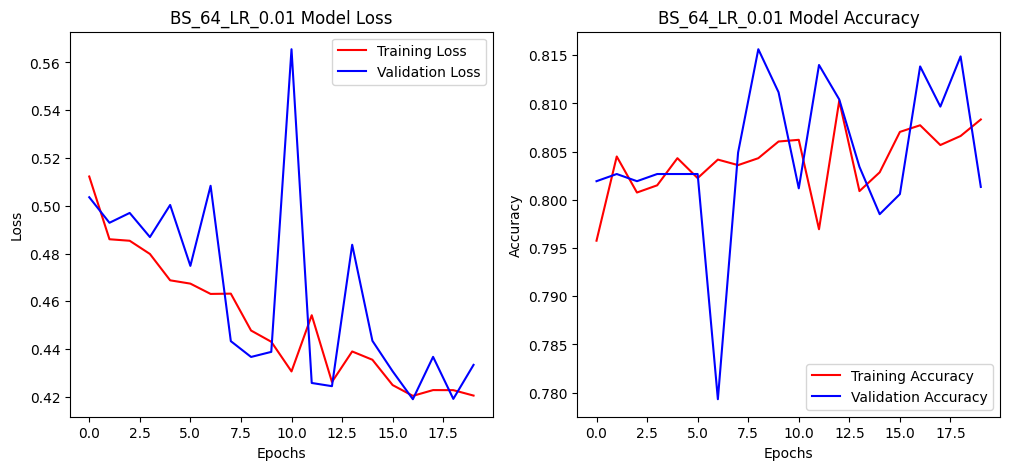

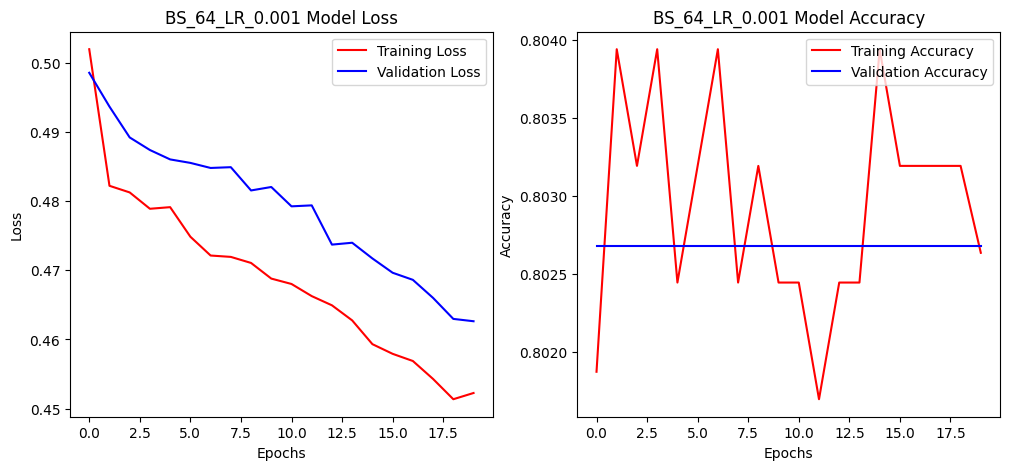

In [60]:
for experiment_name, result in results.items():
  plot_loss_accuracy(epoch_count_list=range(EPOCHS),
                     train_loss_list=result[0],
                     test_loss_list=result[1],
                     train_accuracy_list=result[2],
                     test_accuracy_list=result[3],
                     expeirment_name=experiment_name)

## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

1. There is no processing step involved apart from turning the dataset into dataloaders so that batching is possible.

2. Lower batch size and higher learning rate causes the model to underfit and at a batch size of 32 and learning rate of 0.001 the model starts to generalize better.

3. The batch size, learning rate and epochs choices can really influenced the results of the model.

## 8. My insights

The Batch size of 32 to 64 seem to be the sweet spot for traning the model as it generalizes well. The change in learning rate doesn't really seem to affect the graph much when it's in the range of 32 to 64.